<a href="https://colab.research.google.com/github/gapalfaro-cmyk/Proyecto-de-fin-de-modulo-7---Alfaro-Badillo-Cruz-Perez-Rupit/blob/main/Programacion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tarea 1

# Sección 1:  SGD y variantes en regresión logística

## Descripción del problema
Clasificar imágenes de sangre (BloodMNIST) en los 8 tipos que existen.

## Metodología
### 1. SGD y SGD + Momentum

# Resultados (y Programación)

*   Instalación de Librerías
*   EDA
*   Regresión logística SGD (Vainilla)
*   Regresión logística SGD + Momentum
*   Comparativo de los modelos

In [19]:
# Librerías necesarias para el código
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
!pip install medmnist
from medmnist import BloodMNIST
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import log_loss, accuracy_score, classification_report

In [45]:
# Bases de datos
train_dataset = BloodMNIST(split='train', download=True)
val_dataset = BloodMNIST(split='val', download=True)
test_dataset = BloodMNIST(split='test', download=True)

# EDA

In [21]:
# Tamaño o número de registros de la base de imágenes
print(f"Train: {len(train_dataset)}")
print(f"Val:   {len(val_dataset)}")
print(f"Test:  {len(test_dataset)}")
print(f"Total: {len(train_dataset) + len(val_dataset) + len(test_dataset)}")

Train: 11959
Val:   1712
Test:  3421
Total: 17092


Frecuencia de imágenes por etiqueta:
0     852
1    2181
2    1085
3    2026
4     849
5     993
6    2330
7    1643
Name: count, dtype: int64


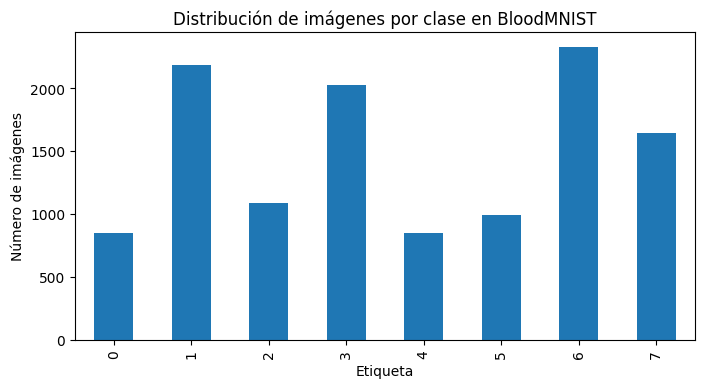

In [31]:
# Tamaño
X_train = train_dataset.imgs
y_train = train_dataset.labels.squeeze()

# Calcular frecuencia por clase
freq = pd.Series(y_train).value_counts().sort_index()

print("Frecuencia de imágenes por etiqueta:")
print(freq)

# Visualizar en gráfico de barras
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
freq.plot(kind="bar")
plt.xlabel("Etiqueta")
plt.ylabel("Número de imágenes")
plt.title("Distribución de imágenes por clase en BloodMNIST")
plt.show()

En la base de entrenamiento se tiene una representatividad mayor en los tipos de sangre 1,3 y 6. Los tipos 0, 4 y 5 con baja representatividad.

**Notas:**
Se revisó en otra programación la representatividad por tipo de sangre en las 3 bases (train, test y val) y la representativodad de los tipos de sangre es  similar.

In [32]:
# Extraer imágenes (X) y etiquetas (y)
X_train = train_dataset.imgs
y_train = train_dataset.labels.squeeze()
X_test = test_dataset.imgs
y_test = test_dataset.labels.squeeze()

# Transformación programática: Aplanar las imágenes de (N, 28, 28, 3) a (N, 2352)
# Usar -1 infiere automáticamente la dimensión restante, adaptándose a cualquier conjunto.
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

# Estandarización de variables
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_flat)
X_test_scaled = scaler.transform(X_test_flat)

# Codificación One-Hot para las etiquetas (preparación para Cross Entropy)
num_classes = len(np.unique(y_train))
y_train_onehot = np.eye(num_classes)[y_train]

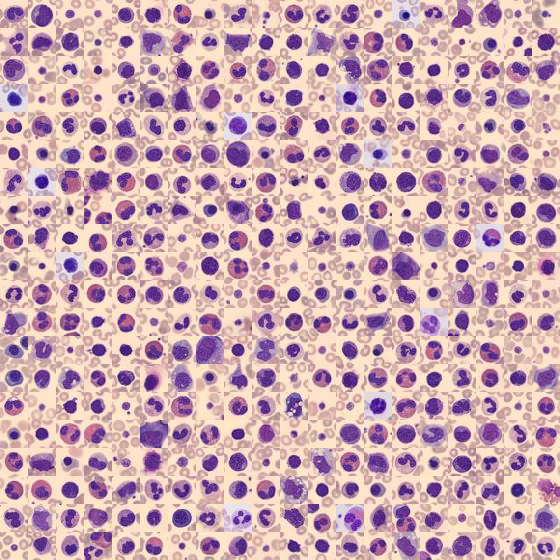

In [33]:
display(train_dataset.montage(length=20))

# Regresión logística: SGD

Época 0/50 - Loss: 1.0496
Época 10/50 - Loss: 0.5807
Época 20/50 - Loss: 0.4986
Época 30/50 - Loss: 0.4543
Época 40/50 - Loss: 0.4222
Época 49/50 - Loss: 0.4017


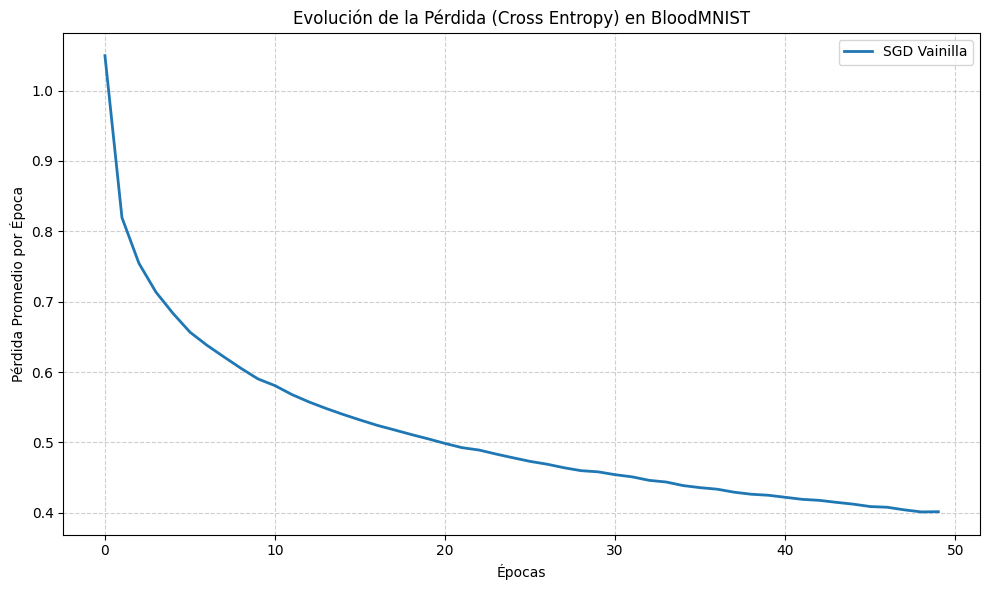

Exactitud (Accuracy) en el conjunto de prueba: 81.06%

Reporte de Clasificación (Desempeño por clase):
              precision    recall  f1-score   support

           0     0.6210    0.6311    0.6260       244
           1     0.9320    0.9439    0.9379       624
           2     0.8464    0.8328    0.8395       311
           3     0.6045    0.6546    0.6285       579
           4     0.8057    0.8189    0.8122       243
           5     0.6875    0.6585    0.6727       284
           6     0.8818    0.8063    0.8424       666
           7     0.9771    0.9979    0.9874       470

    accuracy                         0.8106      3421
   macro avg     0.7945    0.7930    0.7933      3421
weighted avg     0.8137    0.8106    0.8116      3421



In [54]:
class RegresionLogisticaSGD:
    def __init__(self, learning_rate=0.01, epochs=100, batch_size=64):
        self.lr = learning_rate
        self.epochs = epochs
        self.batch_size = batch_size
        self.W = None
        self.b = None
        self.loss_history = []

    def _softmax(self, z):
        # Restar el máximo por estabilidad numérica (evitar overflow)
        z_safe = z - np.max(z, axis=1, keepdims=True)
        exp_z = np.exp(z_safe)
        return exp_z / np.sum(exp_z, axis=1, keepdims=True)

    def _compute_loss(self, y_true, y_pred):
        # Añadir un pequeño epsilon para evitar log(0)
        epsilon = 1e-15
        y_pred = np.clip(y_pred, epsilon, 1 - epsilon)
        # Cross entropy
        return -np.mean(np.sum(y_true * np.log(y_pred), axis=1))

    def fit(self, X, y):
        n_samples, n_features = X.shape
        n_classes = y.shape[1]  # y viene en formato One-Hot

        # Inicialización programática de parámetros
        self.W = np.random.randn(n_features, n_classes) * 0.01
        self.b = np.zeros((1, n_classes))

        for epoch in range(self.epochs):
            # Mezclar los datos en cada época para la naturaleza estocástica
            indices = np.arange(n_samples)
            np.random.shuffle(indices)
            X_shuffled = X[indices]
            y_shuffled = y[indices]

            epoch_loss = 0
            num_batches = 0

            # Iterar sobre mini-lotes
            for i in range(0, n_samples, self.batch_size):
                X_batch = X_shuffled[i:i + self.batch_size]
                y_batch = y_shuffled[i:i + self.batch_size]

                # 1. Forward pass (Puntajes y Activación)
                linear_output = np.dot(X_batch, self.W) + self.b
                y_pred = self._softmax(linear_output)

                # 2. Calcular gradientes
                # El gradiente de la cross entropy con softmax se simplifica a (y_pred - y_true)
                dW = np.dot(X_batch.T, (y_pred - y_batch)) / self.batch_size
                db = np.sum(y_pred - y_batch, axis=0, keepdims=True) / self.batch_size

                # 3. Actualización SGD vainilla (sin momentum, sin adaptación)
                # w = w - lr * gradiente
                self.W -= self.lr * dW
                self.b -= self.lr * db

                epoch_loss += self._compute_loss(y_batch, y_pred)
                num_batches += 1

            # Guardar la pérdida promedio de la época
            self.loss_history.append(epoch_loss / num_batches)

            # Imprimir progreso cada 10 épocas
            if epoch % 10 == 0 or epoch == self.epochs - 1:
                print(f"Época {epoch}/{self.epochs} - Loss: {self.loss_history[-1]:.4f}")

    def predict(self, X):
        linear_output = np.dot(X, self.W) + self.b
        y_pred = self._softmax(linear_output)
        return np.argmax(y_pred, axis=1)

# Instanciar el modelo vainilla (sin momentum)
modelo_sgd = RegresionLogisticaSGD(learning_rate=0.01, epochs=50, batch_size=128)

# Entrenar (usando las mismas variables escaladas y codificadas)
modelo_sgd.fit(X_train_scaled, y_train_onehot)

# Predecir sobre el conjunto de prueba
predicciones_sgd = modelo_sgd.predict(X_test_scaled)

# 1. Gráfica de evolución de la función de pérdida
plt.figure(figsize=(10, 6))
plt.plot(modelo_sgd.loss_history, label='SGD Vainilla', color='#1f77b4', linewidth=2)
plt.title('Evolución de la Pérdida (Cross Entropy) en BloodMNIST')
plt.xlabel('Épocas')
plt.ylabel('Pérdida Promedio por Época')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

# 2. Evaluación cuantitativa y métricas en formato tabular
exactitud = accuracy_score(y_test, predicciones_sgd)
print(f"Exactitud (Accuracy) en el conjunto de prueba: {exactitud * 100:.2f}%\n")

# Generar una tabla de métricas (Precisión, Recall, F1-Score) para las 8 clases de células
reporte = classification_report(y_test, predicciones_sgd, digits=4)
print("Reporte de Clasificación (Desempeño por clase):")
print(reporte)

## Regresión logística: SGD + Momentum

In [34]:
class RegresionLogisticaMomentum:
    def __init__(self, learning_rate=0.01, momentum=0.9, epochs=100, batch_size=64):
        self.lr = learning_rate
        self.gamma = momentum  # Coeficiente de inercia
        self.epochs = epochs
        self.batch_size = batch_size
        self.W = None
        self.b = None
        self.loss_history = []

    def _softmax(self, z):
        # Restar el máximo por estabilidad numérica (evitar overflow)
        z_safe = z - np.max(z, axis=1, keepdims=True)
        exp_z = np.exp(z_safe)
        return exp_z / np.sum(exp_z, axis=1, keepdims=True)

    def _compute_loss(self, y_true, y_pred):
        # Añadir un pequeño epsilon para evitar log(0)
        epsilon = 1e-15
        y_pred = np.clip(y_pred, epsilon, 1 - epsilon)
        # Cross entropy
        return -np.mean(np.sum(y_true * np.log(y_pred), axis=1))

    def fit(self, X, y):
        n_samples, n_features = X.shape
        n_classes = y.shape[1]  # Asumiendo que y viene en formato One-Hot

        # Inicialización programática de parámetros y velocidades
        self.W = np.random.randn(n_features, n_classes) * 0.01
        self.b = np.zeros((1, n_classes))

        v_W = np.zeros_like(self.W)
        v_b = np.zeros_like(self.b)

        for epoch in range(self.epochs):
            # Mezclar los datos en cada época para la naturaleza estocástica
            indices = np.arange(n_samples)
            np.random.shuffle(indices)
            X_shuffled = X[indices]
            y_shuffled = y[indices]

            epoch_loss = 0
            num_batches = 0

            # Iterar sobre mini-lotes
            for i in range(0, n_samples, self.batch_size):
                X_batch = X_shuffled[i:i + self.batch_size]
                y_batch = y_shuffled[i:i + self.batch_size]

                # 1. Forward pass (Puntajes y Activación)
                linear_output = np.dot(X_batch, self.W) + self.b
                y_pred = self._softmax(linear_output)

                # 2. Calcular gradientes
                # El gradiente de la cross entropy con softmax se simplifica a (y_pred - y_true)
                dW = np.dot(X_batch.T, (y_pred - y_batch)) / self.batch_size
                db = np.sum(y_pred - y_batch, axis=0, keepdims=True) / self.batch_size

                # 3. Actualización con Momentum
                v_W = self.gamma * v_W + self.lr * dW
                v_b = self.gamma * v_b + self.lr * db

                self.W -= v_W
                self.b -= v_b

                epoch_loss += self._compute_loss(y_batch, y_pred)
                num_batches += 1

            # Guardar la pérdida promedio de la época
            self.loss_history.append(epoch_loss / num_batches)

            # Imprimir progreso cada 10 épocas
            if epoch % 10 == 0 or epoch == self.epochs - 1:
                print(f"Época {epoch}/{self.epochs} - Loss: {self.loss_history[-1]:.4f}")

    def predict(self, X):
        linear_output = np.dot(X, self.W) + self.b
        y_pred = self._softmax(linear_output)
        return np.argmax(y_pred, axis=1)

In [35]:
# Instanciar el modelo con momentum
modelo_momentum = RegresionLogisticaMomentum(learning_rate=0.01, momentum=0.9, epochs=50, batch_size=128)

# Entrenar (usando las variables escaladas y codificadas que generamos previamente)
modelo_momentum.fit(X_train_scaled, y_train_onehot)

# Predecir sobre el conjunto de prueba
predicciones = modelo_momentum.predict(X_test_scaled)

Época 0/50 - Loss: 0.9669
Época 10/50 - Loss: 0.4551
Época 20/50 - Loss: 0.3871
Época 30/50 - Loss: 0.3441
Época 40/50 - Loss: 0.3178
Época 49/50 - Loss: 0.3196


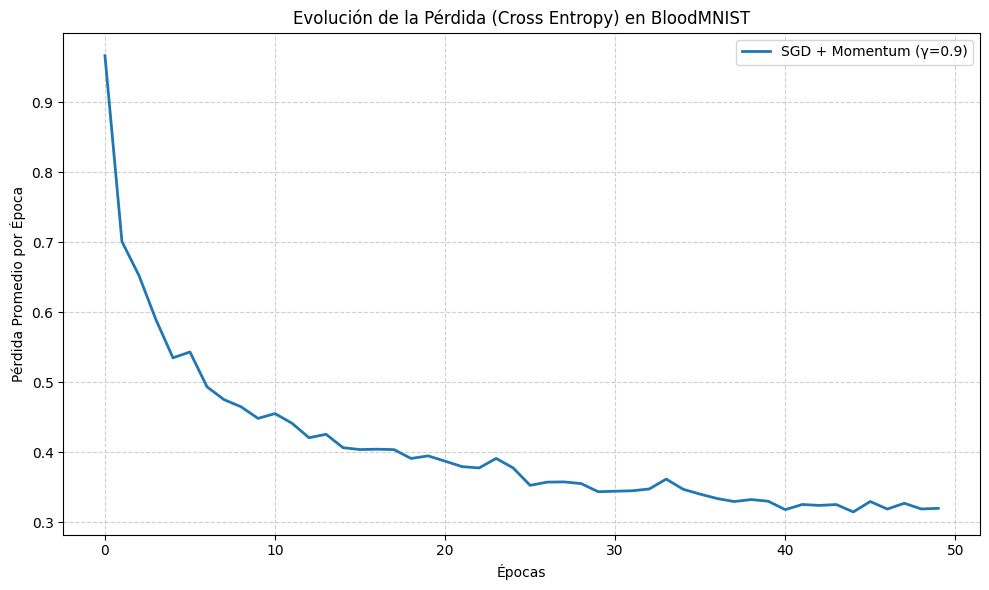

Exactitud (Accuracy) en el conjunto de prueba: 80.33%

Reporte de Clasificación (Desempeño por clase):
              precision    recall  f1-score   support

           0     0.6059    0.5861    0.5958       244
           1     0.9143    0.9407    0.9273       624
           2     0.8313    0.8553    0.8431       311
           3     0.6099    0.6183    0.6141       579
           4     0.7769    0.8025    0.7895       243
           5     0.6429    0.6338    0.6383       284
           6     0.8772    0.8258    0.8507       666
           7     0.9812    0.9979    0.9895       470

    accuracy                         0.8033      3421
   macro avg     0.7799    0.7825    0.7810      3421
weighted avg     0.8029    0.8033    0.8028      3421



In [36]:
# 1. Gráfica de evolución de la función de pérdida
plt.figure(figsize=(10, 6))
plt.plot(modelo_momentum.loss_history, label='SGD + Momentum (γ=0.9)', color='#1f77b4', linewidth=2)
plt.title('Evolución de la Pérdida (Cross Entropy) en BloodMNIST')
plt.xlabel('Épocas')
plt.ylabel('Pérdida Promedio por Época')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

# 2. Evaluación cuantitativa y métricas en formato tabular
exactitud = accuracy_score(y_test, predicciones)
print(f"Exactitud (Accuracy) en el conjunto de prueba: {exactitud * 100:.2f}%\n")

# Generar una tabla de métricas (Precisión, Recall, F1-Score) para las 8 clases de células
reporte = classification_report(y_test, predicciones, digits=4)
print("Reporte de Clasificación (Desempeño por clase):")
print(reporte)

## Comparacion de SGD Vainilla vs SGD + Momentum

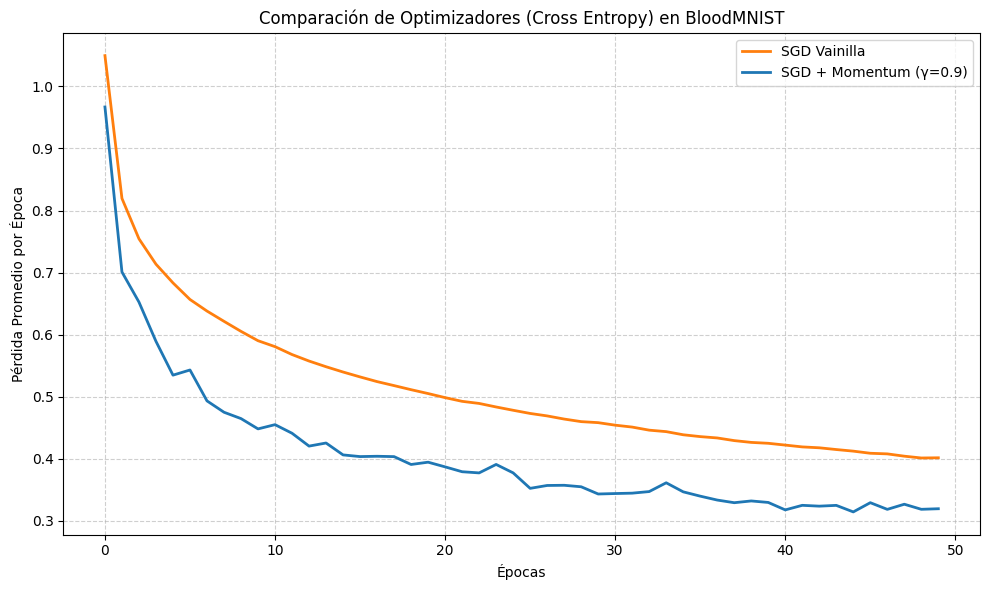

-------------------------
COMPARACIÓN DE ACCURACY
-------------------------
SGD Vainilla:      0.8106
SGD + Momentum:    0.8033
Diferencia:        0.0073

----------------------------------------
REPORTE DE CLASIFICACIÓN - SGD VAINILLA
----------------------------------------
              precision    recall  f1-score   support

           0     0.6210    0.6311    0.6260       244
           1     0.9320    0.9439    0.9379       624
           2     0.8464    0.8328    0.8395       311
           3     0.6045    0.6546    0.6285       579
           4     0.8057    0.8189    0.8122       243
           5     0.6875    0.6585    0.6727       284
           6     0.8818    0.8063    0.8424       666
           7     0.9771    0.9979    0.9874       470

    accuracy                         0.8106      3421
   macro avg     0.7945    0.7930    0.7933      3421
weighted avg     0.8137    0.8106    0.8116      3421


------------------------------------------
REPORTE DE CLASIFICACIÓN - S

In [55]:
plt.figure(figsize=(10, 6))
plt.plot(modelo_sgd.loss_history, label='SGD Vainilla', color='#ff7f0e', linewidth=2)
plt.plot(modelo_momentum.loss_history, label='SGD + Momentum (γ=0.9)', color='#1f77b4', linewidth=2)
plt.title('Comparación de Optimizadores (Cross Entropy) en BloodMNIST')
plt.xlabel('Épocas')
plt.ylabel('Pérdida Promedio por Época')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

# Accuracy de cada modelo
acc_sgd = accuracy_score(y_test, predicciones_sgd)
acc_momentum = accuracy_score(y_test, predicciones)

print("-"*25)
print("COMPARACIÓN DE ACCURACY")
print("-"*25)
print(f"SGD Vainilla:      {acc_sgd:.4f}")
print(f"SGD + Momentum:    {acc_momentum:.4f}")
print(f"Diferencia:        {abs(acc_momentum - acc_sgd):.4f}")

# Classification report de cada modelo
print("\n" + "-"*40)
print("REPORTE DE CLASIFICACIÓN - SGD VAINILLA")
print("-"*40)
print(classification_report(y_test, predicciones_sgd, digits=4))

print("\n" + "-"*42)
print("REPORTE DE CLASIFICACIÓN - SGD + MOMENTUM")
print("-"*42)
print(classification_report(y_test, predicciones, digits=4))

# Conclusiones

El modelo de SGD + Momentum eceleró la convergencia del descenso de gradiente de manera significativamente mejor que SGD. Sin embargo, SGD Vainilla tuvo mayor estabilidad (sin crecimientos y descrecimientos repentinos) que son presentes en SGD + Momentum.

Se observa en la gráfica que la pérdida de 0.5 se presenta en SGD + Momentum en una iteración menor al 10 (alrededor de 7), mientras que en SGD se presenta en la iteración 20.

## 2. SGD en Scikit-learn

# Descripción del problema

# Metodología

Revisión documental: Realizar una revisión de la documentación de scikit-learn sobre el uso de descenso de gradiente estocástico, tanto para regresión como para clasificación. En particular, deberán revisar las clases SGDRegressor y SGDClassifier.



El objetivo del proyecto es explicar cómo se implementa SGD en scikit-learn, qué funciones de pérdida permite usar, qué parámetros son importantes y cómo se relaciona su funcionamiento con lo estudiado en clase. Hacer un ejemplito de uso con datos reales:


1. Revisar la documentación oficial de:
SGDRegressor y SGDClassifier.
2. Explicar el papel de los siguientes elementos:
función de pérdida;
tasa de aprendizaje;
regularización;
número de épocas;
escalamiento de variables;
criterio de parada.
3. Aplicar SGDRegressor a un problema de regresión con una base de datos real. Una opción recomendada es la base California Housing, disponible en scikit-learn, o bien, aplicar SGDClassifier a un problema de clasificación con una base de datos real. Una opción recomendada es la base Breast Cancer Wisconsin, también disponible en scikit-learn.
4. Comparar los resultados con un método de referencia, por ejemplo:
regresión lineal ordinaria para el problema de regresión;
regresión logística para el problema de clasificación.

## 2
- **Función de pérdida (loss):** Es la métrica matemática que el algoritmo intenta minimizar durante el entrenamiento. En SGDClassifier, usar loss='log_loss' implementa regresión logística, mientras que loss='hinge' implementa una Máquina de Vectores de Soporte (SVM). En SGDRegressor, loss='squared_error' minimiza los mínimos cuadrados ordinarios.  
- **Tasa de aprendizaje (learning_rate):** Controla el tamaño del paso que da el optimizador en cada iteración para actualizar los pesos. En scikit-learn, puede ser constante, óptima (disminuye gradualmente basada en una heurística) o adaptativa (disminuye solo cuando el error deja de mejorar).
- **Regularización (penalty):** Es un término de penalización que se añade a la función de pérdida para evitar el sobreajuste (overfitting). Scikit-learn permite penalizaciones L2 (Ridge, encoge los pesos de manera uniforme), L1 (Lasso, fuerza algunos pesos a cero para selección de variables) o Elastic Net (una combinación de ambas).
- **Número de épocas (max_iter):** Representa el número máximo de veces que el algoritmo iterará sobre el conjunto de datos de entrenamiento completo. Si se alcanza este número, el algoritmo se detiene, incluso si no ha convergido idealmente.
- **Escalamiento de variables:** SGD es altamente sensible a la escala de las características (features). Si una variable tiene un rango de 0 a 1000 y otra de 0 a 1, el gradiente estará dominado por la primera, provocando oscilaciones severas. Por ello, es imperativo usar un escalador (como StandardScaler) antes de entrenar.
- **Criterio de parada (tol / early_stopping):** Es la condición lógica que le indica al algoritmo cuándo detenerse antes de alcanzar el número máximo de épocas. Generalmente, se detiene si la pérdida no mejora al menos una cantidad determinada (tol) durante un número específico de épocas continuas.


In [ ]:
# Programación

In [53]:
# Se agrega por si se corre por separado, ya que está en la primera sección de la programación
# Extraer imágenes (X) y etiquetas (y)
X_val = val_dataset.imgs
y_val = val_dataset.labels.squeeze()

# 1. Aplanar imágenes -
# X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_val_flat = X_val.reshape(X_val.shape[0], -1)

# 2. Estandarizar variables
# scaler = StandardScaler()
# X_train_scaled = scaler.fit_transform(X_train_flat)
X_val_scaled   = scaler.transform(X_val_flat) # Este no está en la sección anterior

# 3. Definir el modelo de regresión logística con SGD
log_reg_sgd = SGDClassifier(
    loss="log_loss",        # pérdida de regresión logística (cross entropy)
    penalty="l2",           # regularización L2 (más estable que None), (luego podemos probar L1/L2).
    learning_rate="constant",
    eta0=0.01,              # tasa de aprendizaje fija
    max_iter=1000,          # número de épocas (iteraciones sobre los datos). número máximo de iteraciones
    random_state=42
)

# 4. Entrenar
log_reg_sgd.fit(X_train_scaled, y_train.ravel())

# 5. Evaluar
y_val_pred = log_reg_sgd.predict(X_val_scaled)
print(f"Exactitud en validación: {accuracy_score(y_val, y_val_pred) * 100:.2f}%")

print("\nReporte de clasificación (validación):")
print(classification_report(y_val, y_val_pred))

# 6. Matriz de confusión
print("\nMatriz de confusión:")
print(confusion_matrix(y_val, y_val_pred))

# 7. Evaluar en prueba
X_test_flat = X_test.reshape(X_test.shape[0], -1)
X_test_scaled = scaler.transform(X_test_flat)

y_test_pred = log_reg_sgd.predict(X_test_scaled)
print(f"\nExactitud en prueba: {accuracy_score(y_test, y_test_pred) * 100:.2f}%")

print("\nReporte de clasificación (prueba):")
print(classification_report(y_test, y_test_pred))

print("\nMatriz de confusión (prueba):")
print(confusion_matrix(y_test, y_test_pred))

Exactitud en validación: 71.67%

Reporte de clasificación (validación):
              precision    recall  f1-score   support

           0       0.60      0.41      0.49       122
           1       0.89      0.89      0.89       312
           2       0.78      0.79      0.78       155
           3       0.55      0.59      0.57       290
           4       0.62      0.49      0.55       122
           5       0.50      0.59      0.54       143
           6       0.72      0.71      0.72       333
           7       0.89      0.95      0.92       235

    accuracy                           0.72      1712
   macro avg       0.69      0.68      0.68      1712
weighted avg       0.72      0.72      0.71      1712


Matriz de confusión:
[[ 50   4   2  42   1  10  13   0]
 [  8 278   2   4   1   7  12   0]
 [  0   0 122   6  13   1  12   1]
 [ 20   3   7 170  13  45  28   4]
 [  2   0  13  26  60   0  20   1]
 [  2   0   1  49   0  85   4   2]
 [  2  27   4  14   8  21 238  19]
 [  0   1 

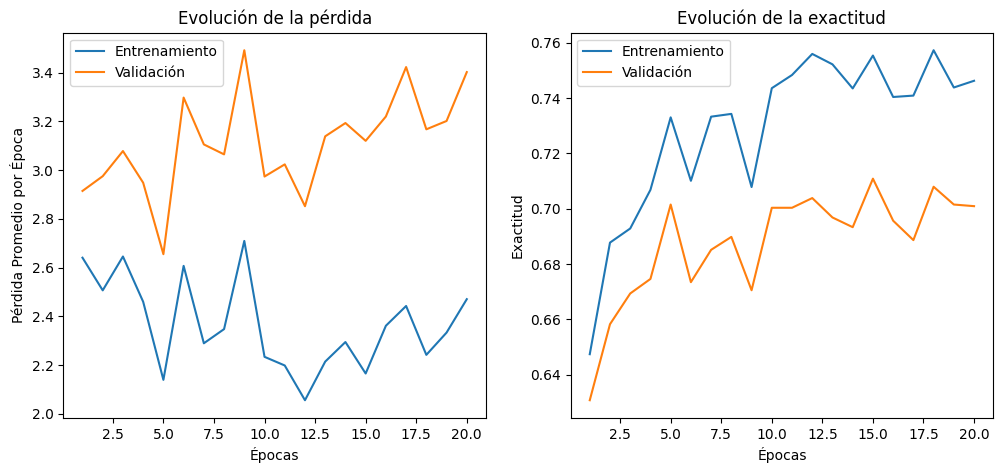

In [59]:
from sklearn.metrics import log_loss, accuracy_score

# Inicializar modelo SGD para regresión logística
sgd_model = SGDClassifier(
    loss="log_loss",
    penalty="l2",
    learning_rate="constant",
    eta0=0.01,
    max_iter=1,        # entrenaremos manualmente con partial_fit
    warm_start=True,
    random_state=42
)

# Inicializar listas para guardar métricas
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

# Entrenamiento manual por épocas
num_epochs = 20
classes = np.unique(y_train)

for epoch in range(num_epochs):
    # Entrenar una época
    sgd_model.partial_fit(X_train_scaled, y_train.ravel(), classes=classes)

    # Predicciones
    y_train_pred = sgd_model.predict_proba(X_train_scaled)
    y_val_pred   = sgd_model.predict_proba(X_val_scaled)

    # Calcular pérdidas (log loss)
    train_loss = log_loss(y_train, y_train_pred)
    val_loss   = log_loss(y_val, y_val_pred)

    # Calcular exactitud
    train_acc = accuracy_score(y_train, np.argmax(y_train_pred, axis=1))
    val_acc   = accuracy_score(y_val, np.argmax(y_val_pred, axis=1))

    # Guardar métricas
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

# Graficar evolución de la pérdida
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(range(1, num_epochs+1), train_losses, label="Entrenamiento")
plt.plot(range(1, num_epochs+1), val_losses, label="Validación")
plt.xlabel("Épocas")
plt.ylabel("Pérdida Promedio por Época")
plt.title("Evolución de la pérdida")
plt.legend()

# Graficar evolución de la exactitud
plt.subplot(1,2,2)
plt.plot(range(1, num_epochs+1), train_accuracies, label="Entrenamiento")
plt.plot(range(1, num_epochs+1), val_accuracies, label="Validación")
plt.xlabel("Épocas")
plt.ylabel("Exactitud")
plt.title("Evolución de la exactitud")
plt.legend()

plt.show()

# Resultados
Se observa que al correr la comprobación del modelo en la base de prueba, la exactitud del modelo baja del 72% al 70%.

# Conclusiones
Lorem ipsum...

### 3. SGD y sus variantes en redes neuronales, escoger uno de los siguientes:
#### 3.1. SGD y sus variantes para clasificación
Usar redes neuronales para un problema de clasificación de imágenes. El
objetivo es comparar el comportamiento de diferentes optimizadores en el
entrenamiento de una misma arquitectura de red neuronal.

Actividades
1. Construir una red neuronal convolucional sencilla para clasificación de
imágenes.
2. Mantener fija la arquitectura de la red y cambiar únicamente el opti-
mizador.
3. Comparar, según la paquetería utilizada, algunos de los siguientes mé-
todos:
SGD clásico;
SGD con momentum;
SGD con momentum de Nesterov;
AdaGrad;
RMSProp;
Adam;
AdamW, si está disponible.
4. Reportar la evolución de la función de pérdida durante el entrenamien-
to.
5. Reportar la exactitud en entrenamiento y validación.
6. Analizar si los optimizadores adaptativos convergen más rápido o si logran mejor desempeño final.

Preguntas a responder
1. ¿Qué optimizador reduce más rápido la función de pérdida?
2. ¿El optimizador con mejor desempeño en entrenamiento también es el
mejor en validación?
3. ¿Qué método parece más sensible a la elección de la tasa de aprendi-
zaje?

#### 3.2. SGD y sus variantes en redes neuronales para regresión
Usar redes neuronales para resolver un problema de regresión con datos reales. El objetivo es comparar el comportamiento de diferentes optimizadores en el entrenamiento de una red neuronal para regresión.

Actividades
1. Explorar la base de datos seleccionada.
2. Separar los datos en entrenamiento, validación y prueba.
3. Estandarizar las variables explicativas.
4. Construir una red neuronal multicapa sencilla.
5. Entrenar la misma arquitectura usando diferentes optimizadores:
SGD;
SGD con momentum;
AdaGrad;
RMSProp;
Adam;
AdamW, si está disponible.
6. Comparar los métodos usando métricas de regresión como:
MSE;
MAE;
RMSE;
R2.
7. Graficar la pérdida de entrenamiento y validación para cada optimiza-
dor.

Preguntas
1. ¿Qué optimizador converge más rápido?
2. ¿Qué optimizador logra menor error de validación?
3. ¿Hay evidencia de sobreajuste?
4. ¿Cómo afecta la tasa de aprendizaje al desempeño?